In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [89]:
import numpy as np
import pandas as pd
import sklearn as sk
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt


# Loading the database

In [5]:
path = '/content/drive/MyDrive/datasets/MLP-UniDisc/stroke.csv'
df = pd.read_csv(path)

# Pre-processing the data

In [6]:
df[df.isnull().any(axis=1)] #show the lines that is lefting some data
df = df.dropna() #removing the rows that are not fully

In [7]:
x = df.iloc[:,1:-1] #remove the id column and remove the stroke column
y = df.iloc[:,-1] #separating the result column to a diff variable
x

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked
...,...,...,...,...,...,...,...,...,...,...
5104,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked


In [8]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
cols = [ 'ever_married', 'Residence_type']
le = LabelEncoder()
x[cols] = x[cols].apply(le.fit_transform)

#for this case that have more than 3 possibilities we use OneHotEncoder, it operation transform each type into a binary number, e.g. using the gender case -  We have 'Male', 'Female' and 'Other',
# Male will be 001 Female 010 and Other 100, using this we avoid to the NN to learn wrongs relations, like Female > Other or something like this
ct = ColumnTransformer(transformers=[('encoders', OneHotEncoder(), ['gender', 'work_type', 'smoking_status'])], remainder = 'passthrough')
x = ct.fit_transform(x)
x[0]

array([  0.  ,   1.  ,   0.  ,   0.  ,   0.  ,   1.  ,   0.  ,   0.  ,
         0.  ,   1.  ,   0.  ,   0.  ,  67.  ,   0.  ,   1.  ,   1.  ,
         1.  , 228.69,  36.6 ])

In [9]:
colunas = ['ohe1', 'ohe2', 'ohe3', 'ohe4', 'ohe5', 'ohe6', 'ohe7', 'ohe8', 'ohe9', 'ohe10', 'ohe11',
           'ohe12', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type',
           'avg_glucose_level', 'bmi']
pd.DataFrame(x, columns=colunas)



,ohe1,ohe2,ohe3,ohe4,ohe5,ohe6,ohe7,ohe8,ohe9,ohe10,ohe11,ohe12,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,67.0,0.0,1.0,1.0,1.0,228.69,36.6
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,80.0,0.0,1.0,1.0,0.0,105.92,32.5
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,49.0,0.0,0.0,1.0,1.0,171.23,34.4
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,79.0,1.0,0.0,1.0,0.0,174.12,24.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,81.0,0.0,0.0,1.0,1.0,186.21,29.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4904,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,13.0,0.0,0.0,0.0,0.0,103.08,18.6
4905,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,81.0,0.0,0.0,1.0,1.0,125.20,40.0
4906,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,35.0,0.0,0.0,1.0,0.0,82.99,30.6
4907,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,51.0,0.0,0.0,1.0,0.0,166.29,25.6


In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.15) #separating the cases of test and training

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train) #normaliza os dados -> média e desvio padrão
x_test = sc.transform(x_test) #normaliza os dados de test com os valores normalizados de x_train


# Building the NN

In [20]:
class NN (nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(19,6),
        nn.ReLU(),
        nn.Linear(6,6),
        nn.ReLU(),
        nn.Linear(6,1),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.layers(x)

In [24]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [25]:
model = NN().to(device)

In [28]:
loss_func = nn.BCELoss()
optimizer = torch.optim.Adam(params= model.parameters(), lr = 0.001)

# Transforming the data in Tensors

In [69]:
# transforma os vetores de x_train e y_train em tensores
x_train_tensor = torch.tensor(x_train, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32, device=device)
# junta os tensores de x e y, formando uma tupla
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
# separa em batchs de tamanho 32 os dados de train_dataset
train_dataloader = DataLoader(train_dataset,batch_size=32,shuffle=True)

x_test_tensor = torch.tensor(x_test, dtype=torch.float32, device = device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32, device = device)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)


# Building the Train and Test Function

In [97]:
def train(model, dataloader, lossfunc, optimizer):
  Y_train_pred = []
  model.train() #treina o modelo -> treina é um método do próprio Pytorch

  cumloss = 0.0
  for data, expect in dataloader:
    data = data.to(device) #é necessário ?
    expect = expect.unsqueeze(1).to(device) #é necessário ?

    pred = model(data) #modelo prediz a resposta a partir dos dados inseridos
    Y_train_pred.append(pred)
    loss = loss_func(pred, expect) # passa as informações que dos dados preditos e compara com os dados esperados
    optimizer.zero_grad() #zera os gradientes acumulados
    loss.backward() #calcula os gradientes em direção de reduzir ele
    optimizer.step() #anda em sentido do menor gradiente (anda o passo calculado)

    cumloss += loss.item() #o que o item() faz ?

  return cumloss/len(dataloader)

def test(model, dataloader, loss_func):
  Y_test_pred = []
  Y_test_true = []
  model.eval() # semelhante ao .train(), mas é melhor para teste
  cumloss = 0.0
  with torch.no_grad(): #turn off gradients computation
    for X, y in dataloader:
      X = X.to(device)
      y = y.unsqueeze(1).to(device)

      pred = model(X)
      loss = loss_func(pred, y)

      cumloss += loss.item()

      pred_binario = torch.round(pred).float()
      Y_test_pred.extend(pred_binario.cpu().numpy().flatten())
      Y_test_true.extend(y.cpu().numpy().flatten())
  return cumloss/len(dataloader), Y_test_pred, Y_test_true

# Training and Testing

In [98]:
epochs = 201
for t in range(epochs):
  train_loss = train(model, train_dataloader, loss_func, optimizer)
  if t % 10 == 0:
    print(f'Epoch {t} - Error: {train_loss}')

test_loss, y_pred, y_true = test(model, test_dataloader,loss_func)
print(f'Test Loss: {test_loss}')


Epoch 0 - Error: 0.12882919283939226
Epoch 10 - Error: 0.1298734397407024
Epoch 20 - Error: 0.12838820875657878
Epoch 30 - Error: 0.12856201303568277
Epoch 40 - Error: 0.12785665097980553
Epoch 50 - Error: 0.12834194035247992
Epoch 60 - Error: 0.12952763349784693
Epoch 70 - Error: 0.1278484130690571
Epoch 80 - Error: 0.12758786662815863
Epoch 90 - Error: 0.12872697776965514
Epoch 100 - Error: 0.12973350779871448
Epoch 110 - Error: 0.12828423891870575
Epoch 120 - Error: 0.12803549963611227
Epoch 130 - Error: 0.12963206288298124
Epoch 140 - Error: 0.12799493604488954
Epoch 150 - Error: 0.12776519945388987
Epoch 160 - Error: 0.12872119043164582
Epoch 170 - Error: 0.127945521192355
Epoch 180 - Error: 0.12902631653287938
Epoch 190 - Error: 0.1283646605851996
Epoch 200 - Error: 0.12795240311165348
Test Loss: 0.1355212296184618


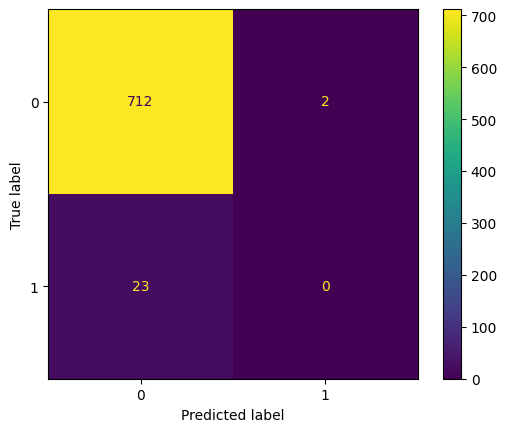

In [99]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.show()

In [100]:
accuracy_score(y_true, y_test)

0.937584803256445